In [2]:
import sys
sys.path.append(rf"/Users/baia/Desktop/PYTHON/mba_dsa_usp_esalq")

from TCC.utils.constantes import *
import matplotlib.pyplot as plt

## S&P500 Close Price
- Retorno logarítmico diário do índice S&P 500. Representa o desempenho das 500 maiores empresas de capital aberto dos EUA.

- É o Beta do Mercado. Na teoria moderna de portfólio, todo ativo tem uma correlação com o mercado (S&P 500). O objetivo é testar se o Bitcoin migrou de "Ativo Descorrelacionado" (Alpha puro) para "Ativo de Alto Beta" (Tech Stock).

- Fonte: https://br.tradingview.com/symbols/SPX/

### HIPÓTESES
## Hipótese 1: Era Varejo (Pré-2020)
Desacoplamento e Fatores Idiossincráticos. Neste período, o Bitcoin era movido predominantemente por fatores endógenos (Halvings, hacks de exchanges, adoção tecnológica). Hipotetiza-se que a correlação com o S&P 500 era estatisticamente nula ou aleatória. Uma queda no mercado acionário tradicional raramente contaminava o preço do Bitcoin no mesmo dia, pois os pools de investidores eram distintos (Varejo/Cypherpunks vs. Wall Street).

## Hipótese 2: Era Institucional (Pós-2020)
O Canal de Transmissão de Risco (Spillover Effect). Com a entrada de algoritmos de paridade de risco e fundos macro, o Bitcoin passou a integrar as cestas de ativos globais. Hipotetiza-se uma forte correlação positiva e causalidade direcional.

S&P 500 Cai: Dispara gatilhos de venda automática em portfólios diversificados para cobrir chamadas de margem, derrubando o preço do Bitcoin (Risk-Off).

S&P 500 Sobe: O aumento do apetite por risco transborda para criptoativos, impulsionando o preço do Bitcoin (Risk-On).

### TRATAMENTO
- Antes de calcular qualquer variação, precisamos preencher esses buracos (valores NaNs aos finais de semana). A técnica padrão é o Forward Fill (ffill): assume-se que o preço de sábado e domingo é igual ao fechamento de sexta-feira. Sem isso, você perderá 30% dos dados da sua série temporal ao alinhar com o Bitcoin.
- Preço com tendência de alta (Não estacionário). Exige Log-Retorno.

In [6]:
df_sp500 = (pd.read_csv(rf"raw/2014_SP500_PRICE.csv")

                         .assign(Data_UTC = lambda df: pd.to_datetime(df['time'], utc=True))
                         .assign(Data_UTC = lambda df: df['Data_UTC'].dt.strftime("%Y-%m-%d"))

                        .rename(columns={'close': 'spx_close'}) 

                        [['Data_UTC', 'spx_close']] 
 
)

df_sp500_log_ret =(
    df_periodo
        .merge(df_sp500, how='left', on='Data_UTC')
        # Preço se mantém ao FDS
        .assign(spx_close = lambda df: df['spx_close'].fillna(method='ffill'))
        .assign(spx_log_ret = lambda df: np.log(df['spx_close']) - np.log(df['spx_close'].shift(1)))
        .assign(Data_UTC = lambda df: pd.to_datetime(df['Data_UTC']))


        .query("Data_UTC > '2017-01-03'")
        [['Data_UTC','spx_close','spx_log_ret']]

)
df_sp500_log_ret

# print_dataframe_info(df_sp500_log_Ret, "S&P 500 Price")

/var/folders/h1/_3z4z04x4j17zlfj224w53hr0000gn/T/ipykernel_3700/4275569698.py:16: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .assign(spx_close = lambda df: df['spx_close'].fillna(method='ffill'))


,Data_UTC,spx_close,spx_log_ret
4,2017-01-04,2270.75,0.005706
5,2017-01-05,2269.00,-0.000771
6,2017-01-06,2276.98,0.003511
7,2017-01-07,2276.98,0.000000
8,2017-01-08,2276.98,0.000000
...,...,...,...
3131,2025-07-28,6389.76,0.000174
3132,2025-07-29,6370.87,-0.002961
3133,2025-07-30,6362.89,-0.001253
3134,2025-07-31,6339.38,-0.003702


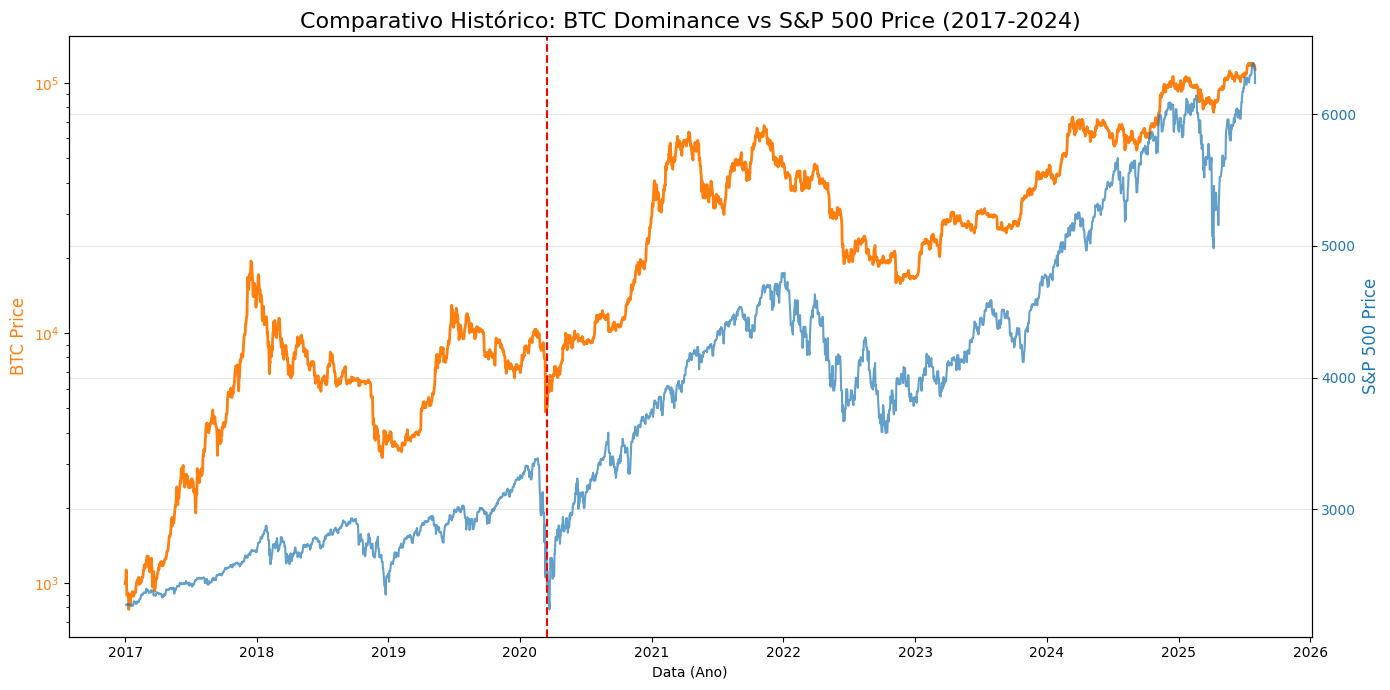

In [7]:
# Configuração do Gráfico
fig, ax1 = plt.figure(figsize=(14, 7)), plt.gca()

# Eixo 1 (Esquerda): BTC Price (Target)
color = 'tab:orange'
ax1.set_xlabel('Data (Ano)')
ax1.set_ylabel('BTC Price', color=color, fontsize=12)
ax1.plot(df_target_price['Data_UTC'], df_target_price['btc_price'], color=color, label='BTC Price', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_yscale('log')

# Eixo 2 (Direita): Variável Macro (ex: S&P 500)
ax2 = ax1.twinx()  # Cria o segundo eixo compartilhando o mesmo X
color = 'tab:blue'
ax2.set_ylabel('S&P 500 Price', color=color, fontsize=12)
ax2.plot(df_sp500_log_ret['Data_UTC'], df_sp500_log_ret['spx_close'], color=color, label='SP500', linewidth=1.5, alpha=0.7)
ax2.tick_params(axis='y', labelcolor=color)

# Formatação
plt.title('Comparativo Histórico: BTC Dominance vs S&P 500 Price (2017-2024)', fontsize=16)
plt.grid(True, alpha=0.3)

# Adicionar linha vertical na Quebra de Regime (Março 2020)
plt.axvline(x=pd.to_datetime('2020-03-15'), color='red', linestyle='--', label='Início Era Institucional (Covid Crash)')

fig.tight_layout()  # Ajusta o layout para não cortar labels
plt.show()

## DXY
- Retorno diário do Índice Dólar (DXY). O índice mede a força do USD contra uma cesta de moedas fortes (Euro, Iene, Libra, etc.)

- O Dólar é o ativo de "refúgio supremo". Quando o DXY sobe, significa que o capital global está fugindo de risco e indo para caixa (Cash is King), o que geralmente drena liquidez de ações e cripto. Quando o DXY cai, a liquidez global se expande, favorecendo ativos de risco.

- Fonte: https://br.tradingview.com/symbols/TVC-DXY/

### HIPÓTESES
## Hipótese 1: Era Varejo (Pré-2020)
Indiferença Cambial. O Bitcoin era visto como "dinheiro mágico da internet", desvinculado das flutuações cambiais das moedas fiduciárias (Fiat). Hipotetiza-se que movimentos no índice Dólar (DXY) tinham baixa importância preditiva (baixo SHAP value) sobre o preço, dado que o driver de valor era a especulação tecnológica e não a macroeconomia monetária.

## Hipótese 2: Era Institucional (Pós-2020)
O Efeito Denominador e Liquidez Global. O Bitcoin passou a ser negociado como uma proxy de liquidez global inversamente correlacionada ao Dólar. Hipotetiza-se uma forte correlação negativa.

DXY Sobe (Dólar Forte): Indica aperto monetário e fuga para liquidez (Cash). O preço do Bitcoin tende a cair, pois é cotado em dólares e sofre com a drenagem de liquidez.

DXY Cai (Dólar Fraco): Indica expansão monetária ou desvalorização fiat, impulsionando o preço do Bitcoin como reserva de valor alternativa ou ativo de risco.

### TRATAMENTO
- O tratamento deve ser robusto. O Forward Fill (ffill) é obrigatório para garantir que, se o dado de segunda faltar, usamos o de domingo/sexta. O mercado cripto não pode ter "buracos".

- Transformação: Como é um índice de preço (Base 100), usamos Log-Retorno.

In [11]:
df_dxy = (pd.read_csv(rf"raw/201501_DXY.csv")

                        .assign(Data_UTC = lambda df: pd.to_datetime(df['time'],unit='s', utc=True))
                        .assign(Data_UTC = lambda df: df['Data_UTC'].dt.strftime("%Y-%m-%d"))
                        .rename(columns={'close': 'dxy_close'}) 

                        [['Data_UTC', 'dxy_close']] 
 
)

df_dxy_log_ret =(
    df_periodo
        .merge(df_dxy, how='left', on='Data_UTC')
        .assign(dxy_close = lambda df: df['dxy_close'].fillna(method='ffill'))
        .assign(dxy_log_ret = lambda df: np.log(df['dxy_close']) - np.log(df['dxy_close'].shift(1)))
        .assign(Data_UTC = lambda df: pd.to_datetime(df['Data_UTC']))

        .query("Data_UTC > '2017-01-03'")
        [['Data_UTC','dxy_close','dxy_log_ret']]
)
df_dxy_log_ret
# print_dataframe_info(df_dxy_log_ret, "S&P 500 Price")

/var/folders/h1/_3z4z04x4j17zlfj224w53hr0000gn/T/ipykernel_3700/2516406768.py:14: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .assign(dxy_close = lambda df: df['dxy_close'].fillna(method='ffill'))


,Data_UTC,dxy_close,dxy_log_ret
4,2017-01-04,102.700,-0.004954
5,2017-01-05,101.520,-0.011556
6,2017-01-06,102.220,0.006872
7,2017-01-07,102.220,0.000000
8,2017-01-08,101.930,-0.002841
...,...,...,...
3131,2025-07-28,98.898,0.002369
3132,2025-07-29,99.887,0.009951
3133,2025-07-30,100.050,0.001631
3134,2025-07-31,98.684,-0.013747


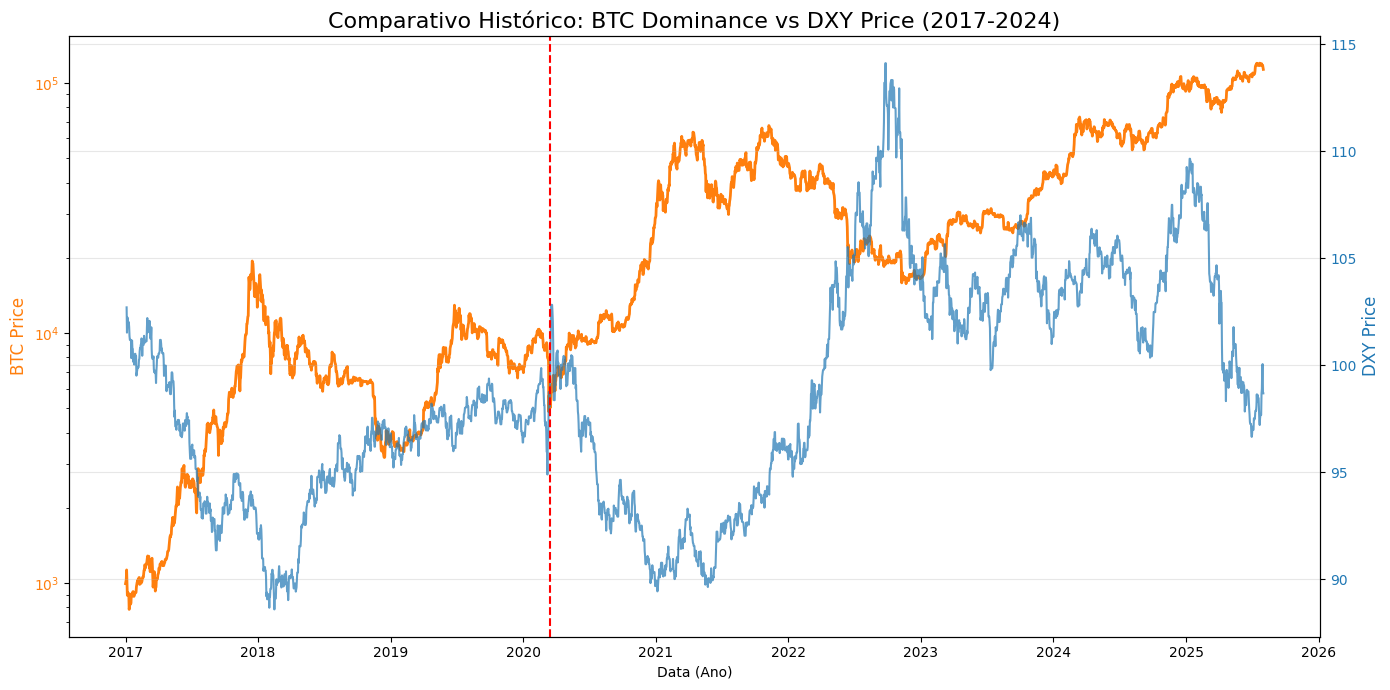

In [12]:
# Configuração do Gráfico
fig, ax1 = plt.figure(figsize=(14, 7)), plt.gca()

# Eixo 1 (Esquerda): BTC Price (Target)
color = 'tab:orange'
ax1.set_xlabel('Data (Ano)')
ax1.set_ylabel('BTC Price', color=color, fontsize=12)
ax1.plot(df_target_price['Data_UTC'], df_target_price['btc_price'], color=color, label='BTC Price', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_yscale('log')

# Eixo 2 (Direita): Variável Macro (ex: S&P 500)
ax2 = ax1.twinx()  # Cria o segundo eixo compartilhando o mesmo X
color = 'tab:blue'
ax2.set_ylabel('DXY Price', color=color, fontsize=12)
ax2.plot(df_dxy_log_ret['Data_UTC'], df_dxy_log_ret['dxy_close'], color=color, label='DXY', linewidth=1.5, alpha=0.7)
ax2.tick_params(axis='y', labelcolor=color)

# Formatação
plt.title('Comparativo Histórico: BTC Dominance vs DXY Price (2017-2024)', fontsize=16)
plt.grid(True, alpha=0.3)

# Adicionar linha vertical na Quebra de Regime (Março 2020)
plt.axvline(x=pd.to_datetime('2020-03-15'), color='red', linestyle='--', label='Início Era Institucional (Covid Crash)')

fig.tight_layout()  # Ajusta o layout para não cortar labels
plt.show()

## NASDAQ
- Retorno diário do índice NASDAQ-100 (as 100 maiores empresas não-financeiras da bolsa americana).
- Serve como proxy para o "Sentimento do Setor de Tecnologia". Como o Bitcoin e o Ethereum são tecnologias emergentes, eles competem pelo mesmo tipo de capital de risco que a Apple, Nvidia e Microsoft.

- Fonte: https://www.nasdaq.com/market-activity/index/comp/historical?page=229&rows_per_page=10&timeline=y10

### HIPÓTESES
## Hipótese 1: Era Varejo (Pré-2020)
Baixa Conectividade Setorial. Embora ambos fossem "tecnologia", o Bitcoin não era tratado como uma ação de Tech. Um crash na Apple ou Google não causava venda automática de Bitcoin. Hipotetiza-se que a correlação entre o NASDAQ e o Bitcoin era baixa e inconsistente, guiada por eventos específicos de cada mercado.

## Hipótese 2: Era Institucional (Pós-2020)
O Bitcoin como "High Beta Tech Stock". Investidores institucionais classificaram o Bitcoin na mesma categoria de risco das ações de tecnologia de alto crescimento (Growth Stocks). Hipotetiza-se que o Bitcoin apresenta a maior correlação positiva dentre todas as variáveis macro, atuando como uma versão alavancada do NASDAQ. Movimentos no índice de tecnologia devem prever (Granger-cause) movimentos amplificados na mesma direção no preço do Bitcoin.

### TRATAMENTO
- Aplica-se a imputação de dias faltantes (ffill) para garantir o alinhamento temporal. O log-retorno mede a variação percentual contínua, permitindo testar a hipótese de acoplamento do Bitcoin como um ativo de tecnologia ("High Beta Tech Stock").

In [7]:
df_nasdaq = (pd.read_csv(rf"raw/nasdaq.csv")

                        # .assign(Data_UTC = lambda df: pd.to_datetime(df['time'],unit='s', utc=True))
                        .assign(Data_UTC = lambda df: pd.to_datetime(df['Date']).dt.strftime("%Y-%m-%d"))
                        .rename(columns={'Close/Last': 'ndx_close'}) 

                        [['Data_UTC', 'ndx_close']] 
 
)
df_nasdaq

df_nasdaq_log_ret =(
    df_periodo
        .merge(df_nasdaq, how='left', on='Data_UTC')
        .assign(ndx_close = lambda df: df['ndx_close'].ffill())
        .assign(ndx_log_ret = lambda df: np.log(df['ndx_close']) - np.log(df['ndx_close'].shift(1)))
        .assign(Data_UTC = lambda df: pd.to_datetime(df['Data_UTC']))

        .query("Data_UTC > '2017-01-03'")
        [['Data_UTC','ndx_close','ndx_log_ret']]
)
df_nasdaq_log_ret
print_dataframe_info(df_nasdaq_log_ret, "NASDAQ Price")


Informações do NASDAQ Price

DESCRIBE:
                  Data_UTC     ndx_close  ndx_log_ret
count                 3132   3132.000000  3132.000000
mean   2021-04-18 12:00:00  11618.802114     0.000427
min    2017-01-04 00:00:00   5477.000000    -0.131492
25%    2019-02-25 18:00:00   7779.670000    -0.001588
50%    2021-04-18 12:00:00  11509.740000     0.000000
75%    2023-06-10 06:00:00  14532.762500     0.004438
max    2025-08-01 00:00:00  21178.580000     0.114784
std                    NaN   4103.051640     0.011995

--------------------------------------------------

INFO:
<class 'pandas.core.frame.DataFrame'>
Index: 3132 entries, 4 to 3135
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Data_UTC     3132 non-null   datetime64[ns]
 1   ndx_close    3132 non-null   float64       
 2   ndx_log_ret  3132 non-null   float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 97.9 KB
None

---

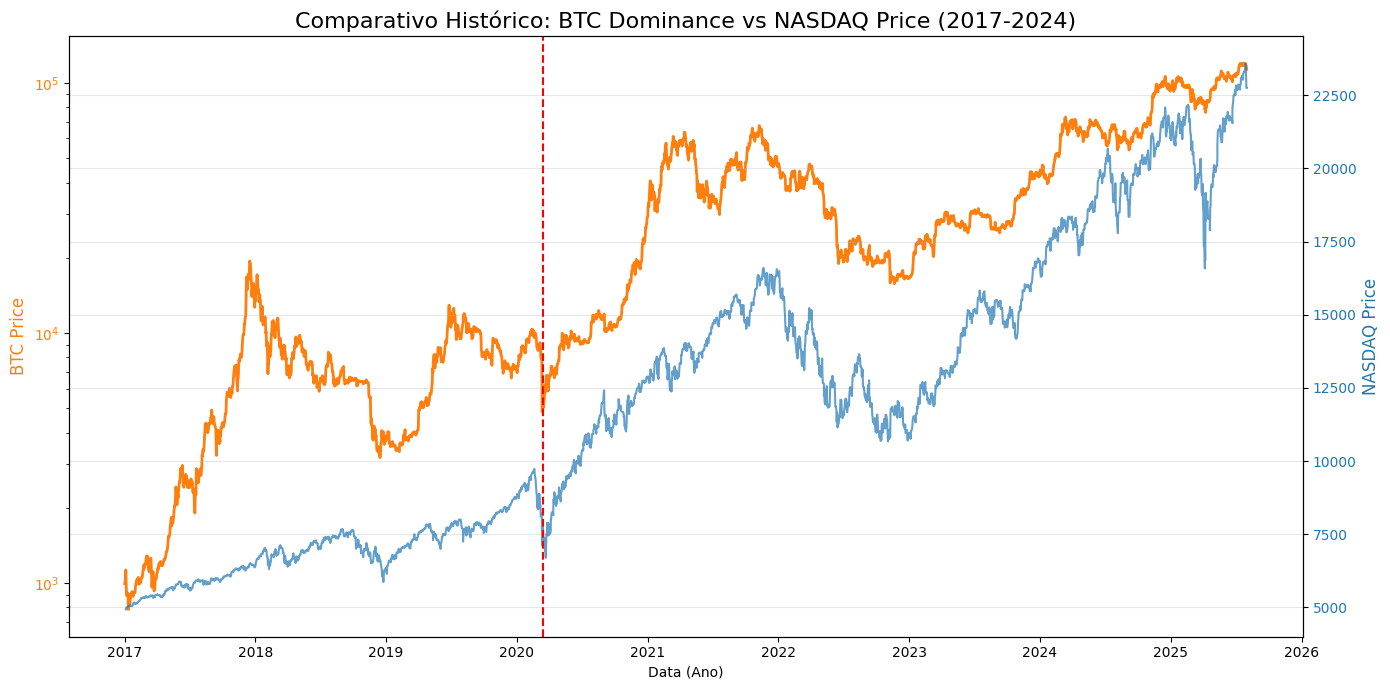

In [14]:
# Configuração do Gráfico
fig, ax1 = plt.figure(figsize=(14, 7)), plt.gca()

# Eixo 1 (Esquerda): BTC Price (Target)
color = 'tab:orange'
ax1.set_xlabel('Data (Ano)')
ax1.set_ylabel('BTC Price', color=color, fontsize=12)
ax1.plot(df_target_price['Data_UTC'], df_target_price['btc_price'], color=color, label='BTC Price', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_yscale('log')

# Eixo 2 (Direita): Variável Macro (ex: S&P 500)
ax2 = ax1.twinx()  # Cria o segundo eixo compartilhando o mesmo X
color = 'tab:blue'
ax2.set_ylabel('NASDAQ Price', color=color, fontsize=12)
ax2.plot(df_nasdaq_log_ret['Data_UTC'], df_nasdaq_log_ret['ndx_close'], color=color, label='NASDAQ', linewidth=1.5, alpha=0.7)
ax2.tick_params(axis='y', labelcolor=color)

# Formatação
plt.title('Comparativo Histórico: BTC Dominance vs NASDAQ Price (2017-2024)', fontsize=16)
plt.grid(True, alpha=0.3)

# Adicionar linha vertical na Quebra de Regime (Março 2020)
plt.axvline(x=pd.to_datetime('2020-03-15'), color='red', linestyle='--', label='Início Era Institucional (Covid Crash)')

fig.tight_layout()  # Ajusta o layout para não cortar labels
plt.show()

## GOLD
- Retorno diário do preço do Ouro à vista (Spot) ou Futuros. O Ouro é o ativo de segurança clássico contra incerteza geopolítica e inflação monetária.
- Testa a narrativa do "Ouro Digital". Em momentos de crise (inflação alta ou guerra), o Ouro sobe. A questão é: o Bitcoin sobe junto (comportamento institucional de proteção) ou cai junto com ações de tecnologia (comportamento de risco)?

- Fonte: https://br.tradingview.com/symbols/XAUUSD/

### HIPÓTESES
## Hipótese 1: Era Varejo (Pré-2020)
Segmentação de Mercado. O perfil do investidor de Ouro (conservador) era oposto ao do investidor de Bitcoin (especulador). Hipotetiza-se que havia descorrelação (indiferença). Movimentos no preço do metal precioso não exerciam influência estatística sobre o preço do ativo digital.

## Hipótese 2: Era Institucional (Pós-2020)
A Narrativa do "Ouro Digital" vs. Realidade. Apesar da narrativa de reserva de valor, a hipótese para este período é complexa. Espera-se uma correlação positiva condicional, mas mais fraca que a das ações.

Cenário de Inflação Monetária: Ouro e Bitcoin sobem juntos (hedge contra desvalorização fiduciária).

Cenário de Liquidez (Juros Reais): Se o Ouro cai por aumento de juros reais, o Bitcoin tende a cair também, mas com maior volatilidade (beta), comportando-se mais como ativo de risco do que como refúgio seguro.

### TRATAMENTO
- Log-Retorno (após Forward Fill)
- Justificativa: Como ativo tradicional, exige imputação de valores (ffill) para fins de semana/feriados. O log-retorno permite a comparação direta da volatilidade e correlação com o Bitcoin, testando a hipótese do BTC como "Ouro Digital".

In [ ]:
df_gold = (pd.read_csv(rf"raw/201501_PRICE_GOLD.csv")

                        .assign(Data_UTC = lambda df: pd.to_datetime(df['time'],unit='s', utc=True))
                        .assign(Data_UTC = lambda df: df['Data_UTC'].dt.strftime("%Y-%m-%d"))
                        .rename(columns={'close': 'close_price'}) 

                        [['Data_UTC', 'close_price']] 
 
)
df_gold

df_gold_log_ret =(
    df_periodo
        .merge(df_gold, how='left', on='Data_UTC')
        .assign(close_price = lambda df: df['close_price'].ffill())
        .assign(GOLD_Log_Ret = lambda df: np.log(df['close_price']) - np.log(df['close_price'].shift(1)))
        

        .query("Data_UTC > '2017-01-03'")
        [['Data_UTC','close_price','GOLD_Log_Ret']]

)
df_gold_log_ret
# print_dataframe_info(df_gold_log_ret, "GOLD Price")

,Data_UTC,close_price,GOLD_Log_Ret
4,2017-01-04,1180.200,0.014337
5,2017-01-05,1172.130,-0.006861
6,2017-01-06,1172.130,0.000000
7,2017-01-07,1172.130,0.000000
8,2017-01-08,1180.750,0.007327
...,...,...,...
3131,2025-07-28,3327.115,0.004041
3132,2025-07-29,3275.817,-0.015538
3133,2025-07-30,3289.830,0.004269
3134,2025-07-31,3362.640,0.021890


## US10Y
- Diferença diária da taxa de rendimento dos títulos do Tesouro Americano de 10 anos. Não usamos retornos logarítmicos para taxas de juros, usamos a diferença aritmética (pontos base).

- É o denominador do Valuation global. Todo ativo de risco (Ações, Imóveis, Bitcoin) compete com essa taxa. Se o governo americano paga 5% sem risco, por que arriscar em Altcoins?

- Fonte: https://br.tradingview.com/symbols/TVC-US10Y/

### HIPÓTESES
## Hipótese 1: Era Varejo (Pré-2020)
Insensibilidade à Taxa Livre de Risco. Num ambiente de juros historicamente baixos e estáveis, o trader de varejo ignorava o mercado de títulos (Bond Market). Hipotetiza-se que variações nos Yields tinham nulo poder explicativo sobre a formação de preço do Bitcoin.

## Hipótese 2: Era Institucional (Pós-2020)
O Custo de Oportunidade e Valuation (DCF). Instituições utilizam modelos de Fluxo de Caixa Descontado, onde a taxa livre de risco é o denominador. Hipotetiza-se uma forte causalidade negativa.

US10Y Dispara: O custo do dinheiro aumenta e o valor presente dos ativos de risco cai. O preço do Bitcoin sofre correção severa (Repricing).

US10Y Cai: O custo de oportunidade diminui, incentivando a busca por rendimento (Yield Hunting) em ativos especulativos, favorecendo a alta do preço do Bitcoin.

### TRATAMENTO
- Primeira Diferença (após Forward Fill)
- Justificativa: Tratando-se de uma taxa percentual, utiliza-se a diferença simples para capturar a variação em pontos base (basis points). A imputação (ffill) corrige os dias sem negociação (fins de semana) para alinhar com o mercado cripto.

In [15]:
df_us10y = (pd.read_csv(rf"raw/201501_US10Y.csv")

                        .assign(Data_UTC = lambda df: pd.to_datetime(df['time'],unit='s', utc=True))
                        .assign(Data_UTC = lambda df: df['Data_UTC'].dt.strftime("%Y-%m-%d"))
                        .rename(columns={'close': 'us10y_close'}) 

                        [['Data_UTC', 'us10y_close']] 
 
)
df_us10y

df_us10y_diff =(
    df_periodo
        .merge(df_us10y, how='left', on='Data_UTC')
        .assign(us10y_close = lambda df: df['us10y_close'].ffill())
        .assign(us10y_diff = lambda df: df['us10y_close'].diff())
        .assign(Data_UTC = lambda df: pd.to_datetime(df['Data_UTC']))

        .query("Data_UTC > '2017-01-03'")
        [['Data_UTC','us10y_close','us10y_diff']]

)
df_us10y_diff
# print_dataframe_info(df_us10y_diff, "US10Y Price")

,Data_UTC,us10y_close,us10y_diff
4,2017-01-04,2.4413,-0.0059
5,2017-01-05,2.3479,-0.0934
6,2017-01-06,2.4221,0.0742
7,2017-01-07,2.4221,0.0000
8,2017-01-08,2.4221,0.0000
...,...,...,...
3131,2025-07-28,4.3240,-0.0900
3132,2025-07-29,4.3720,0.0480
3133,2025-07-30,4.3820,0.0100
3134,2025-07-31,4.2160,-0.1660


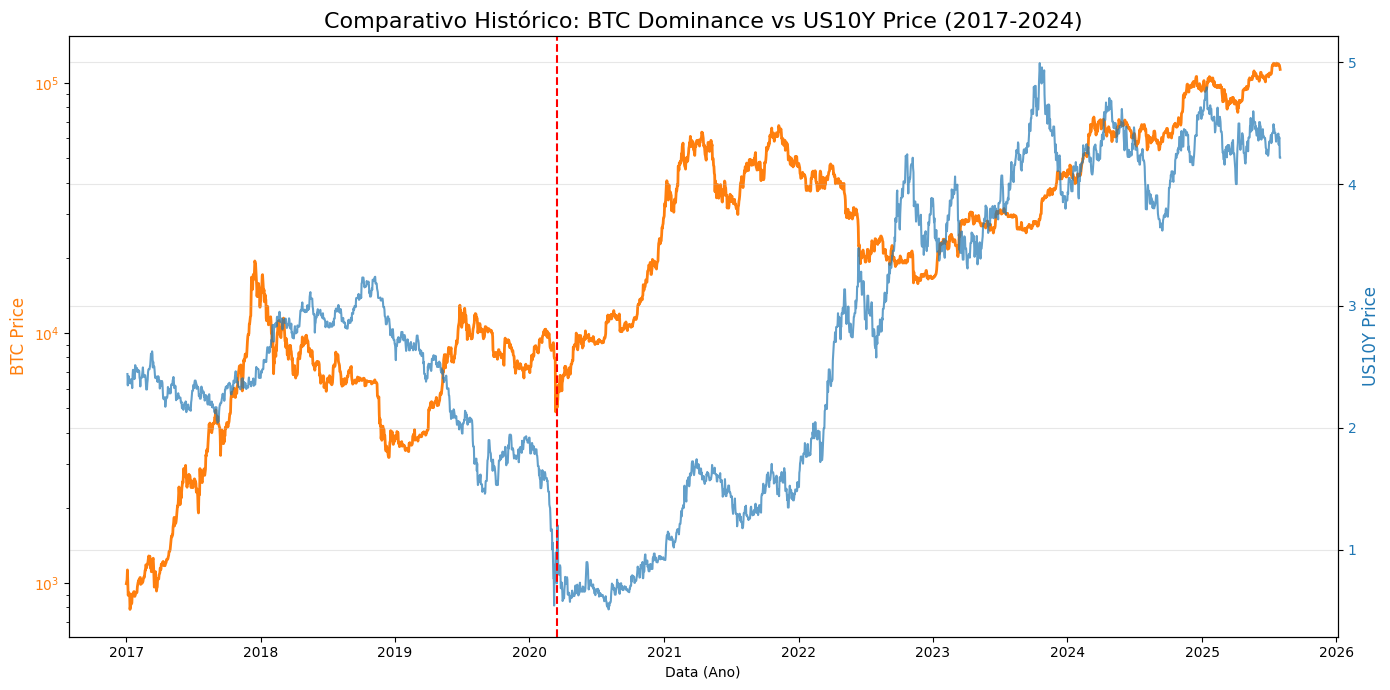

In [16]:
# Configuração do Gráfico
fig, ax1 = plt.figure(figsize=(14, 7)), plt.gca()

# Eixo 1 (Esquerda): BTC Price (Target)
color = 'tab:orange'
ax1.set_xlabel('Data (Ano)')
ax1.set_ylabel('BTC Price', color=color, fontsize=12)
ax1.plot(df_target_price['Data_UTC'], df_target_price['btc_price'], color=color, label='BTC Price', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_yscale('log')

# Eixo 2 (Direita): Variável Macro (ex: S&P 500)
ax2 = ax1.twinx()  # Cria o segundo eixo compartilhando o mesmo X
color = 'tab:blue'
ax2.set_ylabel('US10Y Price', color=color, fontsize=12)
ax2.plot(df_us10y_diff['Data_UTC'], df_us10y_diff['us10y_close'], color=color, label='US10Y', linewidth=1.5, alpha=0.7)
ax2.tick_params(axis='y', labelcolor=color)

# Formatação
plt.title('Comparativo Histórico: BTC Dominance vs US10Y Price (2017-2024)', fontsize=16)
plt.grid(True, alpha=0.3)

# Adicionar linha vertical na Quebra de Regime (Março 2020)
plt.axvline(x=pd.to_datetime('2020-03-15'), color='red', linestyle='--', label='Início Era Institucional (Covid Crash)')

fig.tight_layout()  # Ajusta o layout para não cortar labels
plt.show()

## VIX
- Retorno logarítmico diário do índice VIX. O VIX não é um ativo investível diretamente (embora existam futuros), é uma estatística.
- Mede o custo do seguro de carteira (Puts). Quando o VIX explode, significa que grandes fundos estão pagando qualquer preço para proteger suas carteiras. É o sinal mais puro de Pânico.

- Fonte: https://br.tradingview.com/symbols/TVC-VIX/

### HIPÓTESES
## Hipótese 1: Era Varejo (Pré-2020)
Medos Distintos (Desacoplamento). O pânico em Wall Street (ex: Guerra Comercial) nem sempre chegava ao ecossistema cripto com a mesma intensidade. O Bitcoin tinha seus próprios ciclos de medo (ex: Banimento na China) que não eram capturados pelo VIX. Hipotetiza-se uma correlação fraca entre o "Índice do Medo" tradicional e o preço do Bitcoin.

## Hipótese 2: Era Institucional (Pós-2020)
Aversão Global ao Risco (Flight to Safety). O Bitcoin perdeu sua característica de refúgio isolado. Hipotetiza-se uma forte correlação negativa com o VIX.

VIX Dispara (Pânico): Investidores institucionais liquidam posições em ativos de risco para preservar capital. O preço do Bitcoin cai abruptamente.

VIX Estável/Cai: Indica complacência e ambiente favorável para Risk-On, permitindo a apreciação do preço do Bitcoin.

### TRATAMENTO
- O VIX mede volatilidade implícita (já é uma porcentagem). No entanto, diferentemente da taxa de juros (US10Y) que se move em pontos base lentos, o VIX tem explosões exponenciais.
- Exemplo: Ir de 12 para 24 (+100%) é um choque de pânico maciço. Ir de 60 para 72 (+20%) é grave, mas o mercado já está em pânico.
- O Log-Retorno é superior aqui. Ele captura a "Aceleração do Medo" em termos percentuais, normalizando os picos de 2020 (Covid) com os picos menores de 2018.
- Tratamento: ffill (obrigatório para fins de semana) + Log-Return

In [17]:
df_vix = (pd.read_csv(rf"raw/201501_VIX.csv")

                        .assign(Data_UTC = lambda df: pd.to_datetime(df['time'],unit='s', utc=True))
                        .assign(Data_UTC = lambda df: df['Data_UTC'].dt.strftime("%Y-%m-%d"))
                        .rename(columns={'close': 'vix_close'}) 

                        [['Data_UTC', 'vix_close']] 
 
)
df_vix

df_vix_log_ret =(
    df_periodo
        .merge(df_vix, how='left', on='Data_UTC')
        .assign(vix_close = lambda df: df['vix_close'].ffill())
        .assign(vix_log_ret = lambda df: np.log(df['vix_close']) - np.log(df['vix_close'].shift(1)))
        .assign(Data_UTC = lambda df: pd.to_datetime(df['Data_UTC']))

        .query("Data_UTC > '2017-01-03'")
        [['Data_UTC','vix_close','vix_log_ret']]

)
df_vix_log_ret
# print_dataframe_info(df_vix_log_ret, "VIX Price")

,Data_UTC,vix_close,vix_log_ret
4,2017-01-04,11.85,-0.081016
5,2017-01-05,11.67,-0.015306
6,2017-01-06,11.32,-0.030450
7,2017-01-07,11.32,0.000000
8,2017-01-08,11.32,0.000000
...,...,...,...
3131,2025-07-28,15.04,0.008011
3132,2025-07-29,15.97,0.059999
3133,2025-07-30,15.47,-0.031809
3134,2025-07-31,16.71,0.077105


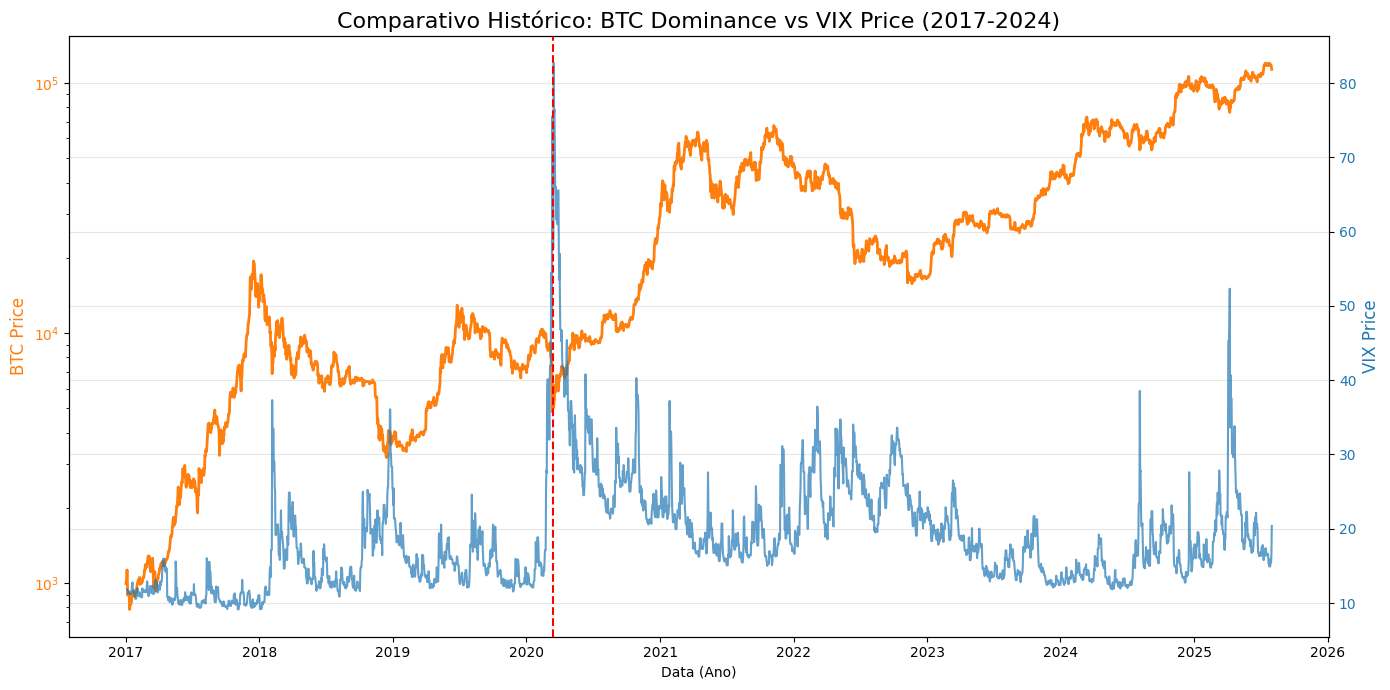

In [18]:
# Configuração do Gráfico
fig, ax1 = plt.figure(figsize=(14, 7)), plt.gca()

# Eixo 1 (Esquerda): BTC Price (Target)
color = 'tab:orange'
ax1.set_xlabel('Data (Ano)')
ax1.set_ylabel('BTC Price', color=color, fontsize=12)
ax1.plot(df_target_price['Data_UTC'], df_target_price['btc_price'], color=color, label='BTC Price', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_yscale('log')

# Eixo 2 (Direita): Variável Macro (ex: S&P 500)
ax2 = ax1.twinx()  # Cria o segundo eixo compartilhando o mesmo X
color = 'tab:blue'
ax2.set_ylabel('VIX Price', color=color, fontsize=12)
ax2.plot(df_vix_log_ret['Data_UTC'], df_vix_log_ret['vix_close'], color=color, label='VIX', linewidth=1.5, alpha=0.7)
ax2.tick_params(axis='y', labelcolor=color)

# Formatação
plt.title('Comparativo Histórico: BTC Dominance vs VIX Price (2017-2024)', fontsize=16)
plt.grid(True, alpha=0.3)

# Adicionar linha vertical na Quebra de Regime (Março 2020)
plt.axvline(x=pd.to_datetime('2020-03-15'), color='red', linestyle='--', label='Início Era Institucional (Covid Crash)')

fig.tight_layout()  # Ajusta o layout para não cortar labels
plt.show()